In [5]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset =load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

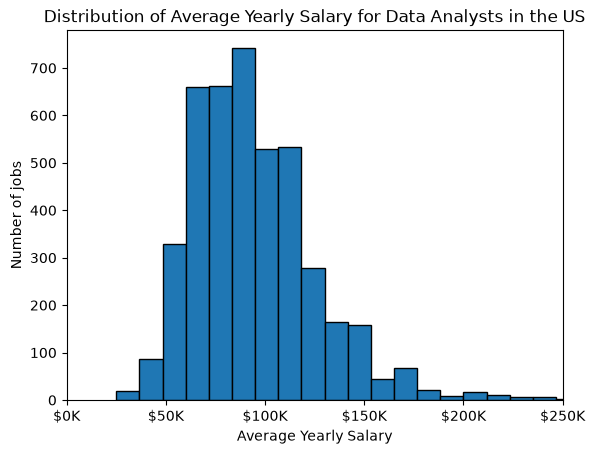

In [20]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')
plt.xlim(0, 250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

plt.title('Distribution of Average Yearly Salary for Data Analysts in the US')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Number of jobs')
plt.show()